In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Seed_Data.csv"

cols= ["area","perimeter","compactness", "length", "width", "asymmetry", "groove", "class"]
# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dongeorge/seed-from-uci",
  file_path
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.columns = cols

print("First 5 records:", df.head())

/tmp/ipykernel_1592/3087563443.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'seed-from-uci' dataset.
First 5 records:     area  perimeter  compactness  length  width  asymmetry  groove  class
0  15.26      14.84       0.8710   5.763  3.312      2.221   5.220      0
1  14.88      14.57       0.8811   5.554  3.333      1.018   4.956      0
2  14.29      14.09       0.9050   5.291  3.337      2.699   4.825      0
3  13.84      13.94       0.8955   5.324  3.379      2.259   4.805      0
4  16.14      14.99       0.9034   5.658  3.562      1.355   5.175      0


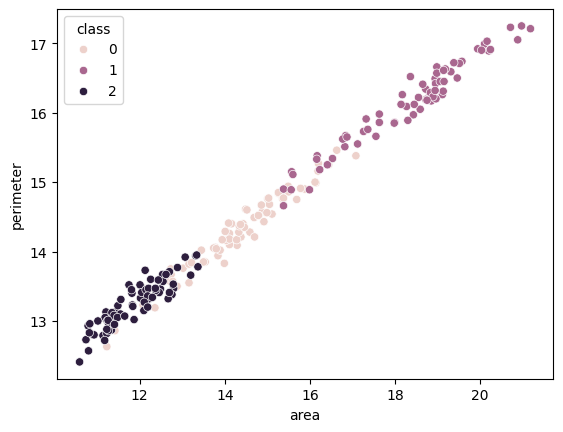

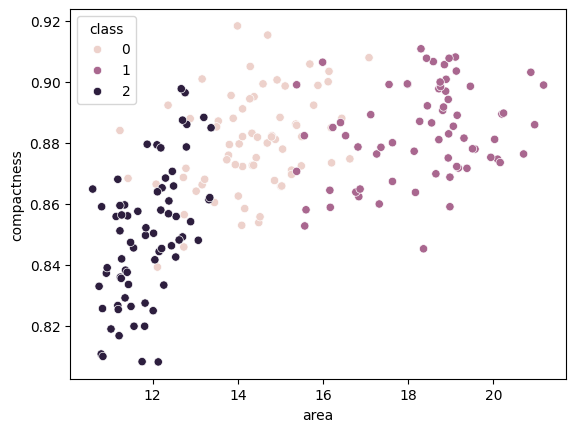

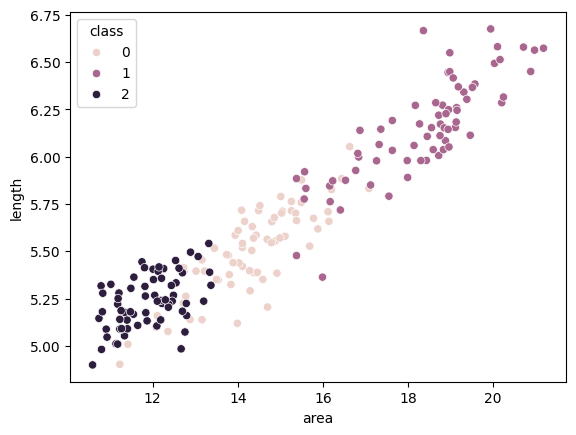

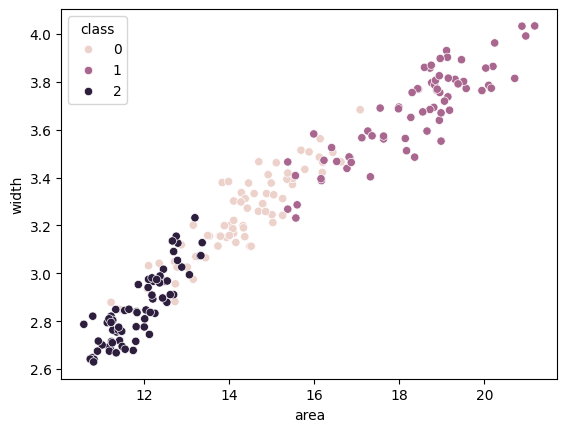

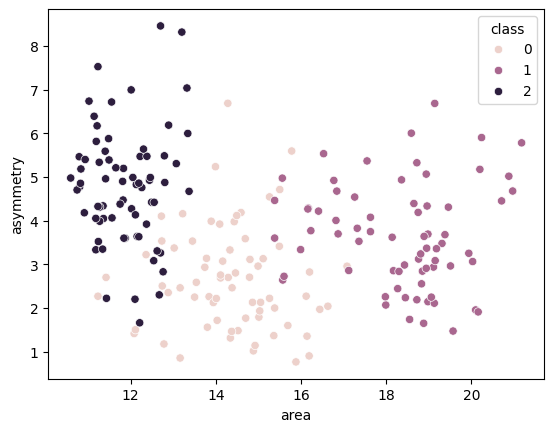

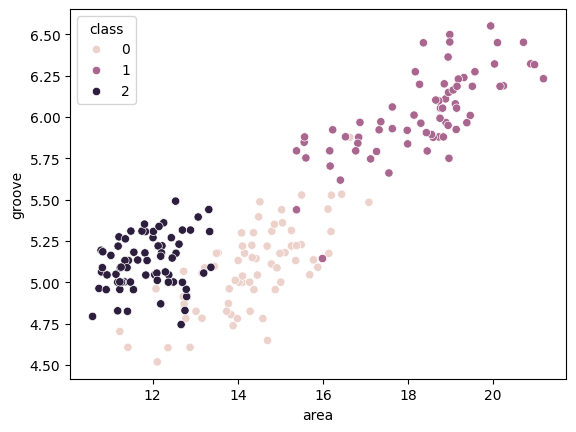

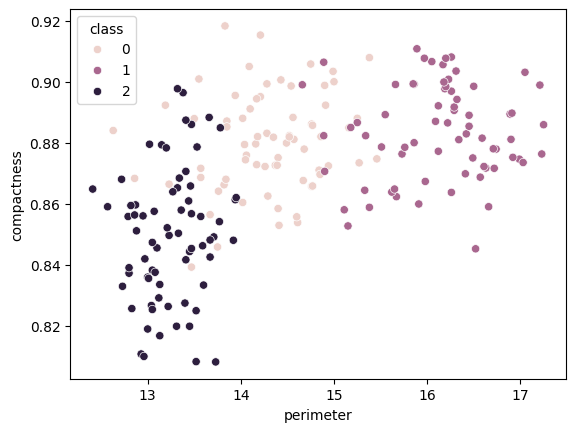

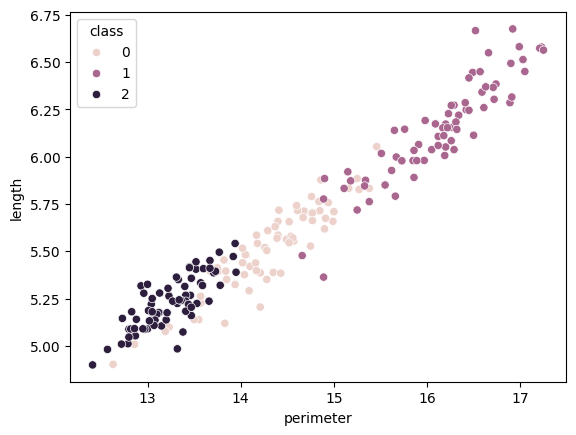

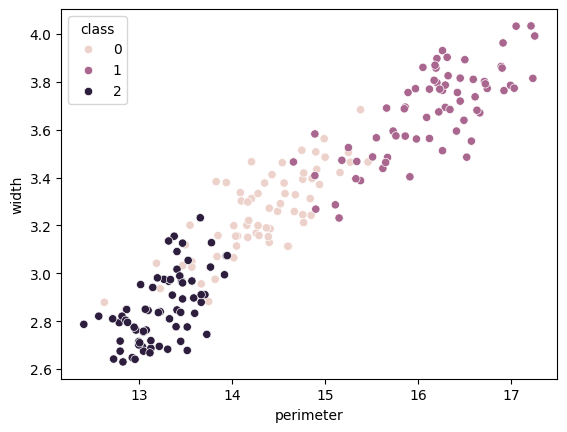

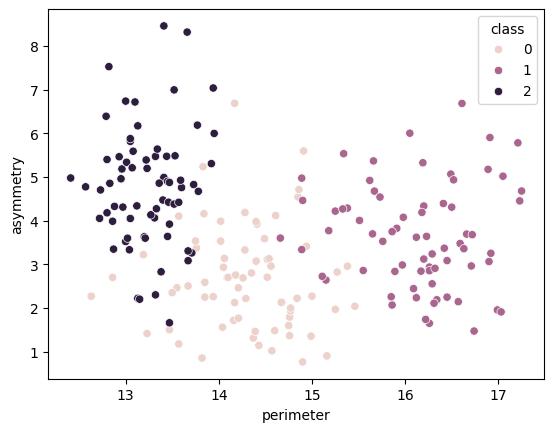

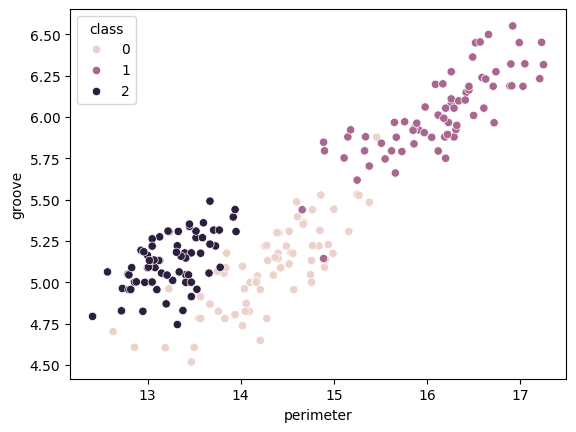

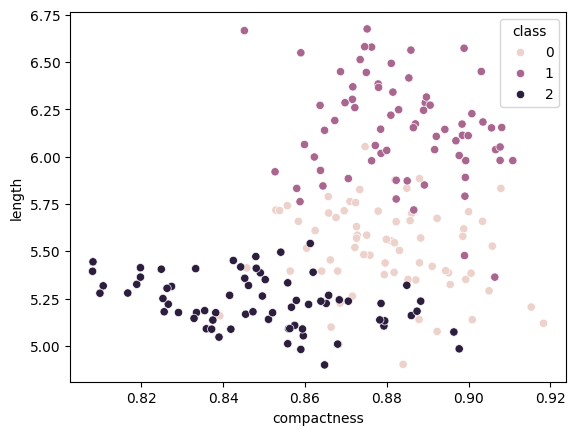

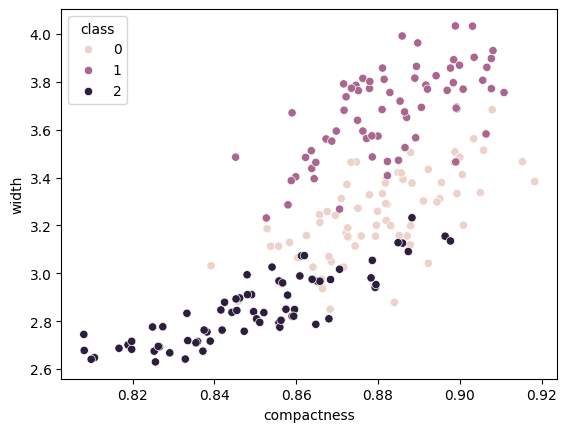

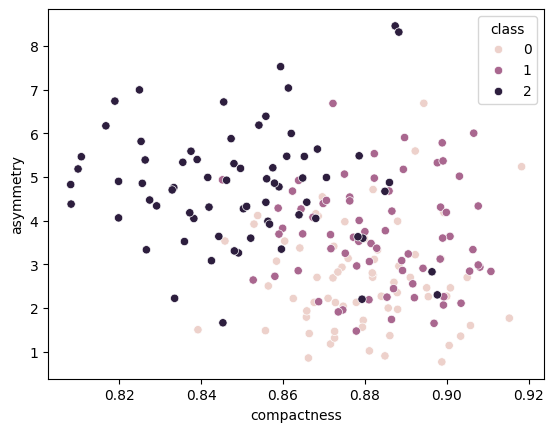

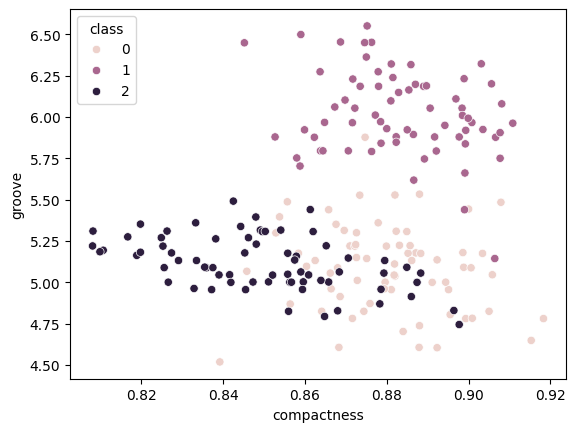

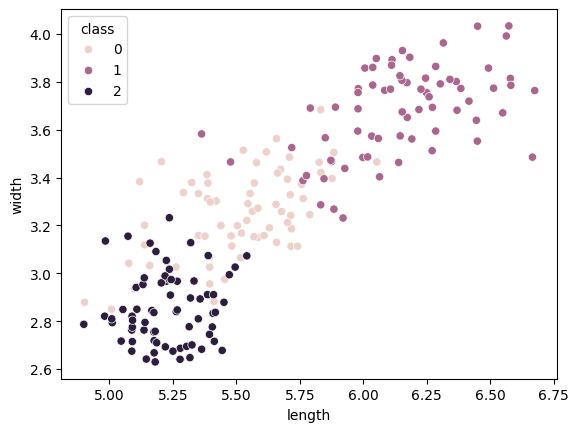

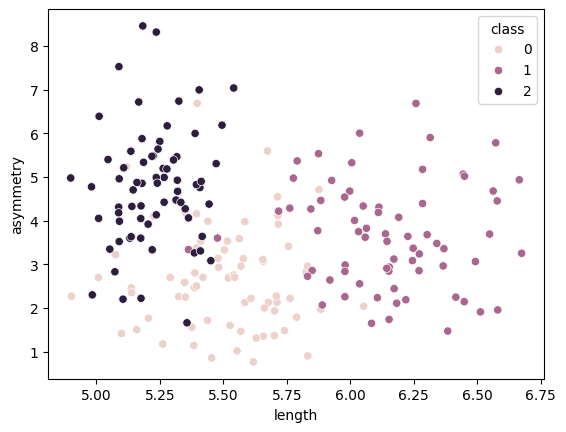

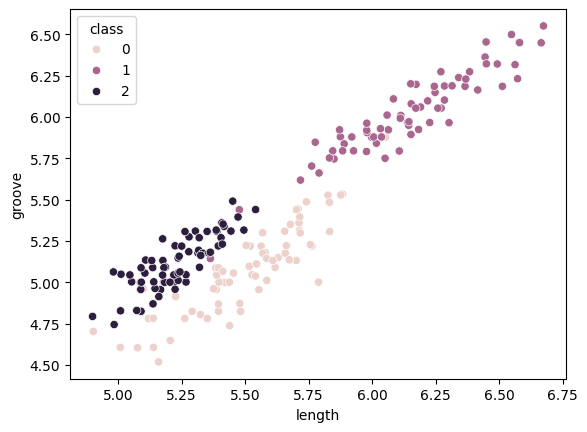

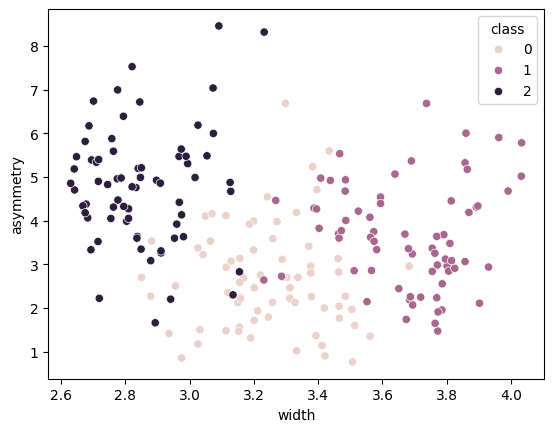

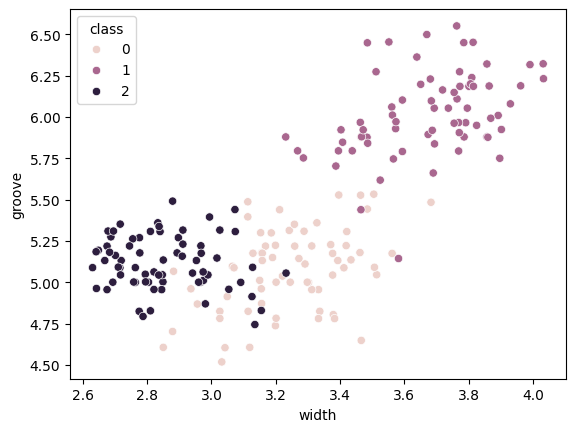

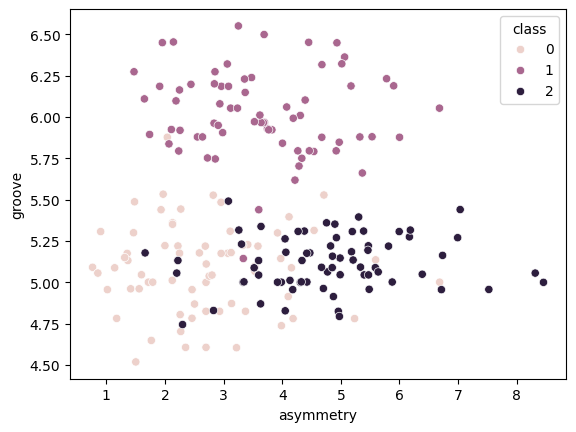

In [9]:
for i in range(len(cols)-1):
  for j in range(i+1, len(cols)-1):
    x_label = cols[i]
    y_label = cols[j]
    sns.scatterplot(x=x_label, y=y_label, data=df, hue="class")
    plt.show()

#Clustering

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [11]:
x="perimeter"
y="asymmetry"
X=df[[x,y]].values

In [12]:
kmeans = KMeans(n_clusters=3).fit(X)

In [13]:
clusters = kmeans.labels_

In [17]:
cluster_df = pd.DataFrame(np.hstack((X, clusters.reshape(-1,1))), columns=[x,y, "class"])

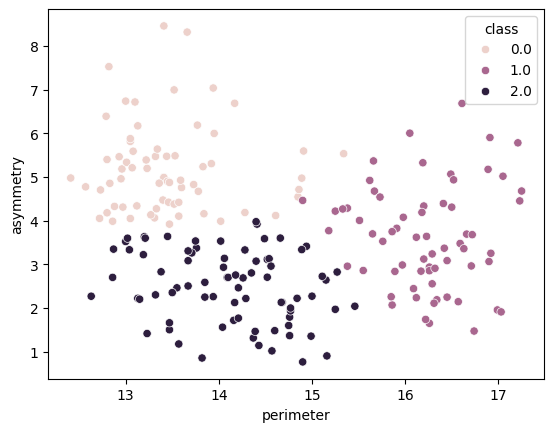

In [18]:
#KMeans Classes

sns.scatterplot(x=x, y=y, data=cluster_df, hue="class")
plt.show()

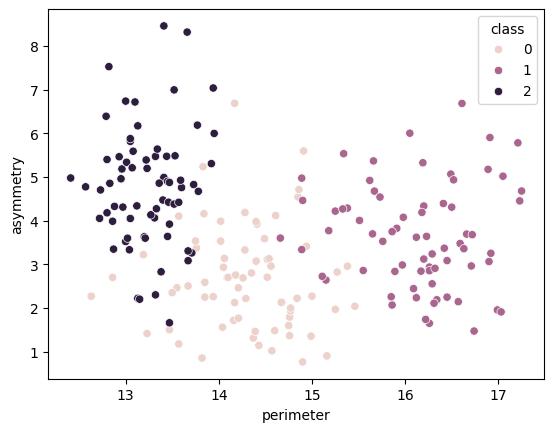

In [19]:
#Original Classes

sns.scatterplot(x=x, y=y, data=df, hue="class")
plt.show()

#Higher Dimensions

In [20]:
X= df[cols[:-1]].values

In [22]:
kmeans = KMeans(n_clusters=3).fit(X)
clusters = kmeans.labels_
cluster_df = pd.DataFrame(np.hstack((X, clusters.reshape(-1,1))), columns=df.columns)

In [26]:
x="compactness"
y="asymmetry"

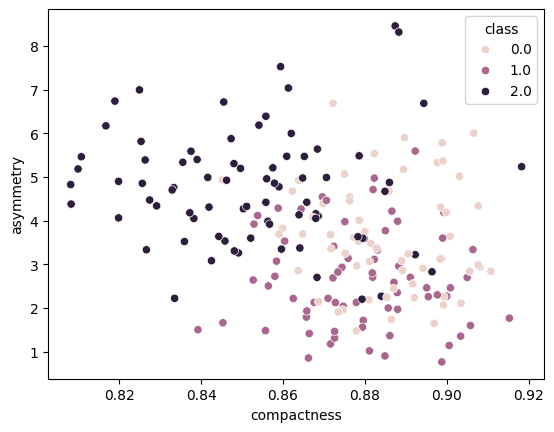

In [27]:
#KMeans Classes

sns.scatterplot(x=x, y=y, data=cluster_df, hue="class")
plt.show()


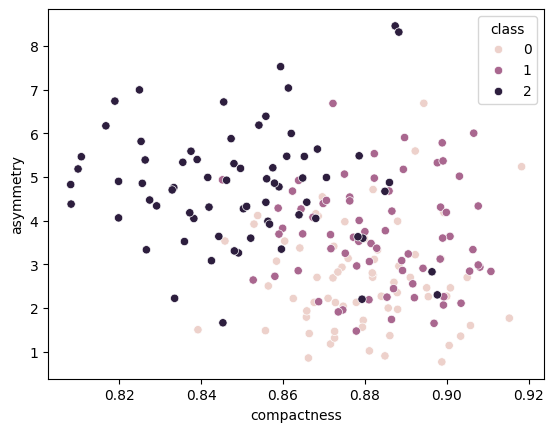

In [28]:
#Original Classes

sns.scatterplot(x=x, y=y, data=df, hue="class")
plt.show()

#PCA

In [29]:
from sklearn.decomposition import PCA

In [30]:
pca = PCA(n_components=2)
transformed_x = pca.fit_transform(X)

In [31]:
X.shape

(210, 7)

In [32]:
transformed_x.shape

(210, 2)

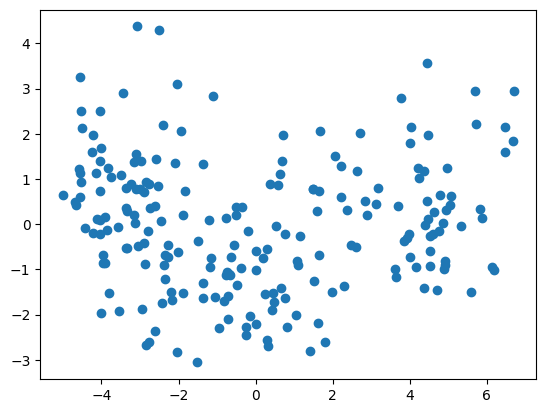

In [33]:
plt.scatter(transformed_x[:,0], transformed_x[:,1])
plt.show()

In [34]:
kmeans_pca_df = pd.DataFrame(np.hstack((transformed_x, kmeans.labels_.reshape(-1,1))), columns=["PC1", "PC2", "class"])

In [35]:
truth_pca_df = pd.DataFrame(np.hstack((transformed_x, df["class"].values.reshape(-1,1))), columns=["PC1", "PC2", "class"])

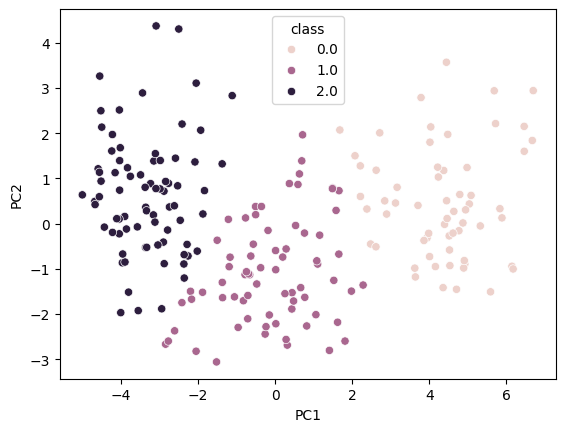

In [37]:
#KMeans Classes

sns.scatterplot(x="PC1", y="PC2", data=kmeans_pca_df, hue="class")
plt.show()

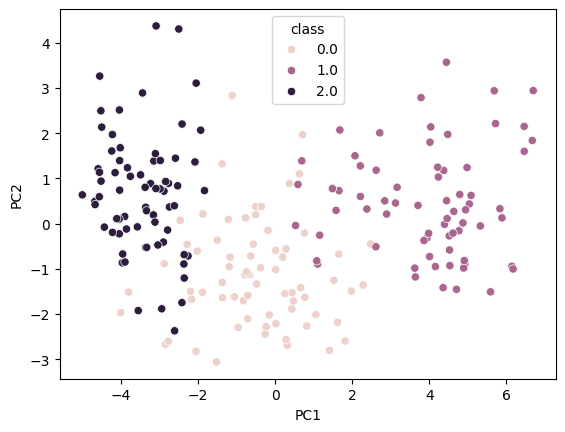

In [38]:
#True  Classes

sns.scatterplot(x="PC1", y="PC2", data=truth_pca_df, hue="class")
plt.show()